# 05. MD with fine-tuned CHGNet models on Li–Y–Cl: activation energy, NPT stability and 5 ns runs

The CHGNet models fine-tuned in notebook 01 (and pretrained CHGNet) were used for Li diffusion MD in
Li<sub>15</sub>Y<sub>7</sub>Cl<sub>36</sub> (58 atoms).

**MD.** CHGNet `MolecularDynamics` with its default Berendsen thermostat (NVT: `NVTBerendsen`;
NPT: inhomogeneous NPT Berendsen at 1 atm), τ<sub>T</sub> = 100 Δt, τ<sub>P</sub> = 1000 Δt, Δt = 1 fs
(2 fs for the 600 K and 700 K long runs), frames every 100 steps. NVT: 400,000 steps (400 ps) at
19–32 temperatures between 300 and 1000 K. NPT: 400 ps, and a set of runs targeting 5 ns
(5,000,000 steps) that stopped at the 144 h wall time after 3.5–6.1 ns. All runs start from the same
AIMD structure; the first 10 ps (20 ps at 2 fs) are discarded. Berendsen thermostats do not sample the
canonical ensemble exactly; they were the package default at the time.

**Training labels.** "first N frames (900 K block)" are contiguous subsets of the AIMD frame table,
which contain 900 K frames only; "energy-histogram" sets are drawn evenly over the energy distribution
of all 500–900 K frames (notebook 01).

### Diffusion analysis (same for every MD notebook in this repository)

Implemented in `iondiff/` (adapted from the MoGroup diffusion module; method of X. He, Y. Zhu, A. Epstein,
Y. Mo, *npj Comput. Mater.* **4**, 18 (2018)):

* **Trajectory**: jobs that continue a previous job (first frame identical to the previous last frame)
  are concatenated after dropping the duplicated frame; equilibration frames are removed only at the
  start of each chain. NPT displacements use each frame's own cell.
* **MSD**: time-averaged (FFT) mean squared displacement of the mobile ion, with the framework
  centre-of-mass drift removed; fitted linearly between MSD = 0.5 a² and 0.8 of the trajectory length
  (a = 3.38 Å, average hop distance), requiring at least 0.5 a² of MSD change. D = slope / 6.
* **Statistical error of D**: RSD = 3.43 / √N<sub>jump</sub> + 0.04 with N<sub>jump</sub> = n<sub>ions</sub>
  · max(MSD) / a² (He et al. 2018); σ<sub>D</sub> = RSD · D.
* **Framework melting**: a temperature is marked *melted* when the framework (all non-mobile atoms)
  diffuses, i.e. their time-averaged MSD at the end of the fit window exceeds a². Isolated framework
  hops (a few atoms moving > 4 Å) do not count; they are recorded separately.
* **Arrhenius fit (primary)**: least squares on log<sub>10</sub>D vs 1000/T, weighted by
  σ<sub>log10 D</sub>, using temperatures where the MSD fit succeeded and the framework did not melt.
  Fits that keep melted temperatures, and unweighted fits, are shown for comparison.
* **Conductivity**: Nernst–Einstein, σ = n z² e² D / (V k<sub>B</sub> T); σ(300 K) is extrapolated
  from the fit (the range comes from the fit uncertainty).

In [1]:
import json
import numpy as np
import pandas as pd
from plot_style import plt, save, PALETTE
import md_results as mr

nvt = mr.load("chgnet_lyc_finetuned_nvt")
npt = mr.load("chgnet_lyc_npt")
training = {r["label"]: r for r in json.load(open("../results/training_runs.json"))["runs"] if r["framework"] == "CHGNet"}

def training_run(md_label):
    key = md_label.replace("FT: ", "").replace(", batch 8", "")
    return training.get(key)

t = mr.summary_table(nvt)
t.insert(0, "test force MAE of model (eV/Å)", [training_run(l)["test"]["f_mae"] if training_run(l) else None for l in t.index])
t

,test force MAE of model (eV/Å),temperatures,total analyzed time (ns),MSD fit ok,framework melted,T used in fit (K),Ea (eV),Ea std (eV),R2,sigma(300 K) extrapolated (mS/cm),sigma(300 K) range (mS/cm)
model,,,,,,,,,,,
CHGNet (pretrained),NaN,32,12.5,30,10,300-750 (20),0.175,0.014,0.809,25.19,13.57-46.75
"FT: first 7,980 frames (900 K block), 10 epochs",0.036,19,7.4,17,2,350-900 (15),0.183,0.013,0.955,19.21,11.10-33.25
"FT: first 7,980 frames (900 K block), 200 epochs",0.015,19,7.2,19,0,300-1000 (19),0.195,0.010,0.898,14.77,9.49-22.99
"FT: first 15,960 frames (900 K block), 10 epochs",0.033,19,7.4,18,0,300-1000 (18),0.185,0.010,0.898,21.19,13.78-32.60
"FT: first 15,960 frames (900 K block), 20 epochs",0.029,29,11.3,29,1,300-1000 (28),0.173,0.009,0.913,25.38,17.42-36.98
"FT: first 30,693 frames (900 K block), 10 epochs",0.032,32,12.5,31,0,300-1000 (31),0.185,0.009,0.922,17.35,11.97-25.14
"FT: energy-histogram 8,121 frames, batch 8",0.031,29,11.3,28,0,300-1000 (28),0.198,0.009,0.920,14.25,9.68-20.95
"FT: energy-histogram 16,279 frames, batch 8",0.029,29,11.3,27,1,350-975 (26),0.188,0.009,0.792,18.89,12.77-27.94
"FT: energy-histogram 16,279 frames, batch 16",0.030,29,11.3,27,1,325-1000 (26),0.198,0.010,0.955,15.47,10.25-23.35


'figures/md/chgnet_lyc_finetuned_ea.png'

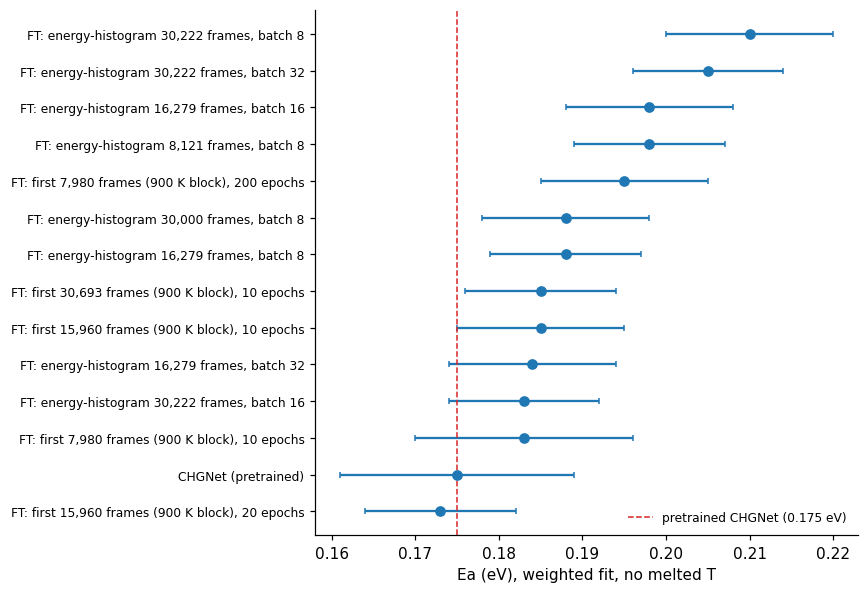

In [2]:
order = t["Ea (eV)"].sort_values().index
fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(order))
ax.errorbar(t.loc[order, "Ea (eV)"], y, xerr=t.loc[order, "Ea std (eV)"], fmt="o", color="C0", capsize=2)
pre = t.loc["CHGNet (pretrained)", "Ea (eV)"]
ax.axvline(pre, color="C1", ls="--", lw=1, label=f"pretrained CHGNet ({pre:.3f} eV)")
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8); ax.set_xlabel("Ea (eV), weighted fit, no melted T")
ax.legend(frameon=False); fig.tight_layout(); save(fig, "md/chgnet_lyc_finetuned_ea")

'figures/md/chgnet_lyc_finetuned_arrhenius.png'

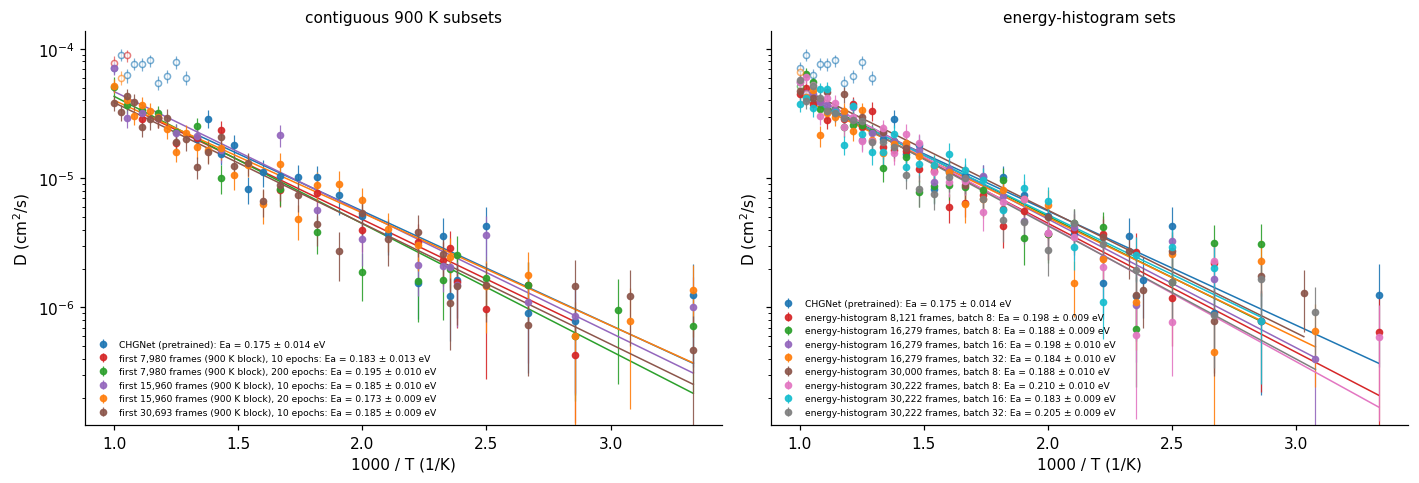

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, keys in zip(axes, [[l for l in t.index if "900 K" in l or "pretrained" in l],
                           [l for l in t.index if "histogram" in l or "pretrained" in l]]):
    for k, c in zip(keys, PALETTE):
        mr.arrhenius_plot(ax, mr.series(nvt, k), c, label=k.replace("FT: ", ""))
    ax.legend(frameon=False, fontsize=6, loc="lower left")
axes[0].set_title("contiguous 900 K subsets"); axes[1].set_title("energy-histogram sets")
fig.tight_layout(); save(fig, "md/chgnet_lyc_finetuned_arrhenius")

## NPT: does the framework stay solid?

Framework MSD at the end of the fit window for every NPT temperature (dashed line: melt criterion a²).

,lowest melted T (K),highest solid T (K)
"FT 7,980 frames, 10 ep: NPT, target 5 ns",550.0,500.0
"FT 7,980 frames, 10 ep: NPT, 400 ps",600.0,550.0
"FT 7,980 frames, 200 ep: NPT, 400 ps",NaN,330.0
"FT 15,960 frames, 10 ep: NPT, 400 ps",425.0,420.0
"FT 30,693 frames, 10 ep: NPT, 400 ps",550.0,500.0
"CHGNet (pretrained): NPT, 400 ps",550.0,500.0


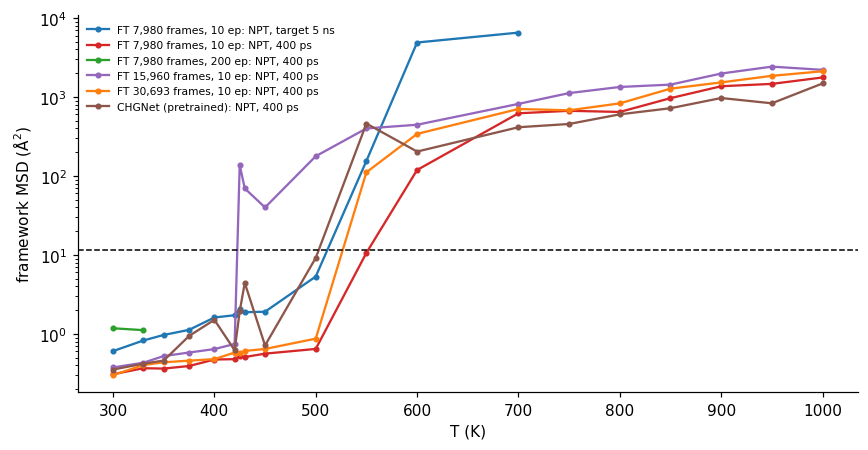

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for s, c in zip(npt["series"], PALETTE):
    T = [r["temperature_K"] for r in s["temperatures"] if r.get("framework_msd_at_fit_end_A2") is not None]
    v = [r["framework_msd_at_fit_end_A2"] for r in s["temperatures"] if r.get("framework_msd_at_fit_end_A2") is not None]
    ax.plot(T, v, "o-", ms=3, color=c, label=s["label"])
ax.axhline(3.38 ** 2, color="k", ls="--", lw=1)
ax.set_yscale("log"); ax.set_xlabel("T (K)"); ax.set_ylabel("framework MSD (Å$^2$)")
ax.legend(frameon=False, fontsize=7); fig.tight_layout(); save(fig, "md/chgnet_lyc_npt_framework_msd")

pd.DataFrame({s["label"]: {"lowest melted T (K)": min([r["temperature_K"] for r in s["temperatures"] if r.get("framework_melt_flag")], default=None),
                           "highest solid T (K)": max([r["temperature_K"] for r in s["temperatures"] if r.get("fit_ok") and not r.get("framework_melt_flag")], default=None)}
              for s in npt["series"]}).T

## NVT: comparison with AIMD (PBE)

The LYC AIMD (500–900 K, the data these models were fine-tuned on) analyzed with the same code and fit
settings. E<sub>a</sub> refitted over the AIMD window and FP/AIMD diffusivity ratios at the AIMD
temperatures (1 = agreement).

In [5]:
aimd = mr.series(mr.load("aimd_lyc"), "AIMD (PBE)")
ea_table, ratio_table = mr.compare_to_aimd(nvt["series"], aimd)
ea_table.join(ratio_table.round(2))

,Ea in AIMD window (eV),Ea std (eV),T used (K),D_FP/D_AIMD at 500 K,D_FP/D_AIMD at 600 K,D_FP/D_AIMD at 700 K,D_FP/D_AIMD at 800 K,D_FP/D_AIMD at 900 K
model,,,,,,,,
AIMD (PBE),0.265,0.045,500-900 (5),NaN,NaN,NaN,NaN,NaN
CHGNet (pretrained),0.180,0.028,500-750 (11),1.94,1.40,1.37,NaN,NaN
"FT: first 7,980 frames (900 K block), 10 epochs",0.178,0.025,500-900 (8),1.66,1.24,1.25,0.80,0.76
"FT: first 7,980 frames (900 K block), 200 epochs",0.266,0.027,500-900 (8),1.54,1.21,1.25,0.83,0.80
"FT: first 15,960 frames (900 K block), 10 epochs",0.160,0.023,500-900 (8),1.89,1.42,1.43,0.93,0.88
"FT: first 15,960 frames (900 K block), 20 epochs",0.171,0.016,500-900 (17),1.87,1.34,1.30,0.82,0.77
"FT: first 30,693 frames (900 K block), 10 epochs",0.201,0.019,500-900 (17),1.55,1.17,1.18,0.76,0.73
"FT: energy-histogram 8,121 frames, batch 8",0.234,0.017,500-900 (17),1.55,1.23,1.28,0.85,0.83
"FT: energy-histogram 16,279 frames, batch 8",0.209,0.019,500-900 (17),1.76,1.34,1.36,0.89,0.85


'figures/md/chgnet_lyc_finetuned_vs_aimd.png'

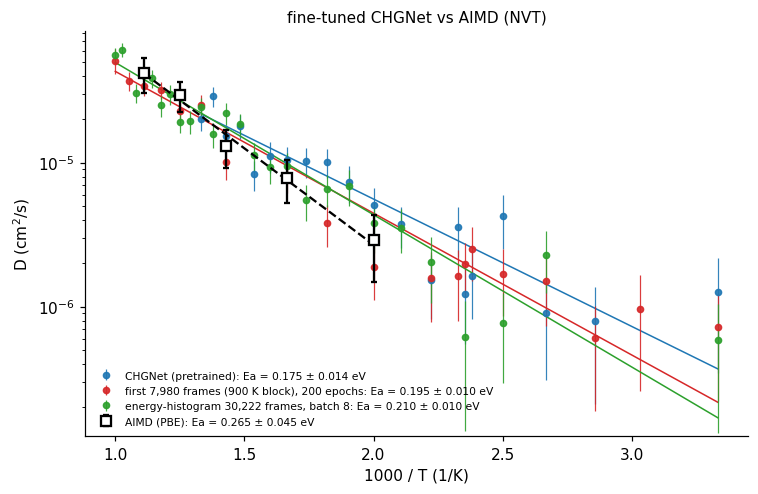

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.6))
for k, c in zip(["CHGNet (pretrained)", "FT: first 7,980 frames (900 K block), 200 epochs",
                 "FT: energy-histogram 30,222 frames, batch 8"], PALETTE):
    mr.arrhenius_plot(ax, mr.series(nvt, k), c, label=k.replace("FT: ", ""), show_melted=False)
mr.aimd_overlay(ax, aimd)
ax.legend(frameon=False, fontsize=7, loc="lower left"); ax.set_title("fine-tuned CHGNet vs AIMD (NVT)")
fig.tight_layout(); save(fig, "md/chgnet_lyc_finetuned_vs_aimd")

## NPT cell volume vs the NVT (AIMD) cell

Mean cell volume of each NPT run, compared with the fixed NVT/AIMD cell. The fine-tuned models were
trained on energies and forces only (no stress), so their pressure, and therefore their NPT volume,
is not constrained by the training data.

In [7]:
v_nvt = mr.series(nvt, "CHGNet (pretrained)")["temperatures"][0]["mean_volume_A3"]
vol = pd.DataFrame({s["label"]: {r["temperature_K"]: r.get("mean_volume_A3") for r in s["temperatures"]} for s in npt["series"]})
print(f"NVT / AIMD cell volume: {v_nvt:.1f} Å^3")
(100 * (vol / v_nvt - 1)).round(1).add_suffix(" (% vs NVT)").loc[[300, 350, 400, 450, 500, 550, 600]]

NVT / AIMD cell volume: 1362.6 Å^3


,"FT 7,980 frames, 10 ep: NPT, target 5 ns (% vs NVT)","FT 7,980 frames, 10 ep: NPT, 400 ps (% vs NVT)","FT 7,980 frames, 200 ep: NPT, 400 ps (% vs NVT)","FT 15,960 frames, 10 ep: NPT, 400 ps (% vs NVT)","FT 30,693 frames, 10 ep: NPT, 400 ps (% vs NVT)","CHGNet (pretrained): NPT, 400 ps (% vs NVT)"
300.0,25.3,25.8,33.1,27.5,26.2,12.5
350.0,26.0,25.7,NaN,29.3,26.5,14.3
400.0,27.2,27.3,NaN,31.9,27.8,16.5
450.0,28.7,28.9,NaN,57.5,29.1,17.7
500.0,31.3,30.4,NaN,97.1,31.8,22.0
550.0,38.9,34.8,NaN,113.5,62.3,26.2
600.0,72.7,50.4,NaN,120.5,103.1,37.7


## The long NPT runs (target 5 ns)

Model: first 7,980 frames (900 K block), 10 epochs. Below are the analyzed lengths and the comparison
with 400 ps NPT runs of the same model at the same temperatures (solid framework only).

In [8]:
long = mr.series(npt, "FT 7,980 frames, 10 ep: NPT, target 5 ns")
short = mr.series(npt, "FT 7,980 frames, 10 ep: NPT, 400 ps")
short_by_T = {r["temperature_K"]: r for r in short["temperatures"]}
rows = []
for r in long["temperatures"]:
    s = short_by_T.get(r["temperature_K"], {})
    rows.append({"T (K)": r["temperature_K"], "time step (fs)": r["frame_interval_fs"] / 100,
                 "analyzed (ns)": round(r.get("analyzed_time_ps", 0) / 1000, 2), "melted": r.get("framework_melt_flag"),
                 "D long (cm2/s)": r.get("D_cm2_s"), "RSD long": r.get("D_rsd"),
                 "D 400 ps (cm2/s)": s.get("D_cm2_s"), "RSD 400 ps": s.get("D_rsd"),
                 "ratio long/400 ps": (r["D_cm2_s"] / s["D_cm2_s"]) if r.get("D_cm2_s") and s.get("D_cm2_s") else None})
long_table = pd.DataFrame(rows).set_index("T (K)")
print(f"total analyzed time of the long runs: {long_table['analyzed (ns)'].sum():.1f} ns")
long_table

total analyzed time of the long runs: 52.2 ns


,time step (fs),analyzed (ns),melted,D long (cm2/s),RSD long,D 400 ps (cm2/s),RSD 400 ps,ratio long/400 ps
T (K),,,,,,,,
300.0,1.0,3.59,False,0.000002,0.171087,0.000003,0.370676,0.683465
330.0,1.0,3.56,False,0.000006,0.125151,0.000004,0.299205,1.410392
350.0,1.0,3.57,False,0.000006,0.122062,0.000009,0.244536,0.672710
375.0,1.0,3.53,False,0.000011,0.103627,0.000010,0.222280,1.151779
400.0,1.0,3.82,False,0.000013,0.097438,0.000011,0.200956,1.177079
420.0,1.0,3.77,False,0.000019,0.086386,0.000021,0.183734,0.893377
425.0,1.0,3.98,False,0.000024,0.078244,0.000021,0.172095,1.122160
430.0,1.0,3.55,False,0.000016,0.096192,0.000014,0.198019,1.142647
450.0,1.0,3.54,False,0.000023,0.079577,0.000035,0.148773,0.645722


,temperatures,total analyzed time (ns),MSD fit ok,framework melted,T used in fit (K),Ea (eV),Ea std (eV),R2,sigma(300 K) extrapolated (mS/cm),sigma(300 K) range (mS/cm)
model,,,,,,,,,,
"FT 7,980 frames, 10 ep: NPT, target 5 ns",13,52.2,13,3,300-500 (10),0.169,0.008,0.954,144.65,97.59-214.41
"FT 7,980 frames, 10 ep: NPT, 400 ps",19,7.4,19,8,300-550 (11),0.185,0.013,0.943,130.71,70.69-241.70
"FT 7,980 frames, 200 ep: NPT, 400 ps",13,0.1,2,0,300-330 (2),NaN,NaN,NaN,NaN,None
"FT 15,960 frames, 10 ep: NPT, 400 ps",19,7.4,19,13,300-420 (6),0.181,0.026,0.806,174.81,47.50-643.39
"FT 30,693 frames, 10 ep: NPT, 400 ps",19,7.4,18,9,330-500 (9),0.176,0.025,0.919,95.86,28.82-318.90
"CHGNet (pretrained): NPT, 400 ps",19,7.4,19,9,300-500 (10),0.129,0.017,0.877,258.55,113.60-588.43


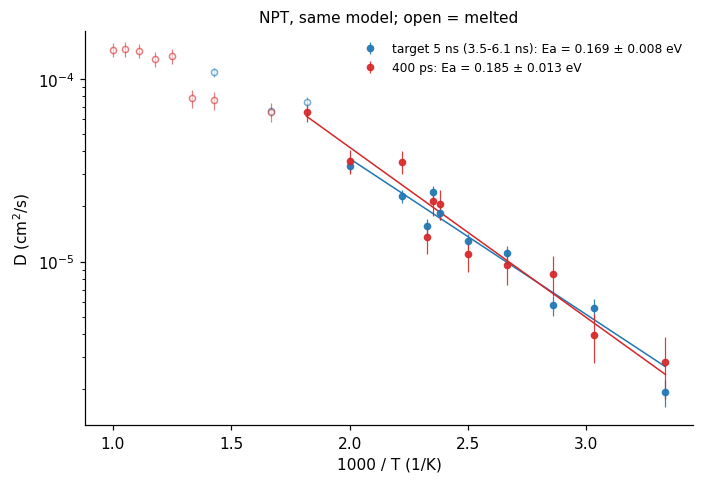

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
mr.arrhenius_plot(ax, long, "C0", label="target 5 ns (3.5-6.1 ns)")
mr.arrhenius_plot(ax, short, "C1", label="400 ps")
ax.legend(frameon=False, fontsize=8); ax.set_title("NPT, same model; open = melted")
fig.tight_layout(); save(fig, "md/chgnet_lyc_npt_long_vs_short")
mr.summary_table(npt)

## Findings

* **NVT, fine-tuned vs pretrained.** The 13 fine-tuned models give E<sub>a</sub> between 0.173 and
  0.210 eV (each ±0.009–0.013 eV), with no consistent trend with training-set size, sampling scheme or
  batch size beyond that spread. Pretrained CHGNet gives 0.175 ± 0.014 eV, but its framework melts at
  10 of 32 temperatures (all above 750 K), while the fine-tuned models melt at 0–2 temperatures:
  fine-tuning on the material's AIMD data mainly stabilizes the framework at high temperature.
* **NPT with these models is not physical.** Every model expands the cell in NPT: pretrained CHGNet by
  13% and the fine-tuned models by 25–33% at 300 K relative to the AIMD cell, and the framework melts
  at 425–600 K. The fine-tuned models were trained without stress, so nothing in their training
  constrains the pressure. Diffusion in these expanded cells is ~10× faster than in NVT at the same
  temperature (e.g. 400 K: 1.3×10⁻⁵ vs 9.7×10⁻⁷ cm²/s), so NPT D and σ values here describe the model's
  expanded cell, not LYC.
* **What the 5 ns runs show.** The long NPT runs (13 temperatures, 3.5–6.1 ns each, 52.2 ns analyzed)
  roughly halve the statistical uncertainty of D relative to 400 ps runs of the same model (RSD 0.08–0.17
  vs 0.15–0.37 at 300–500 K), and D from the two run lengths is consistent within those uncertainties
  (ratio 0.65–1.41). The framework stays solid only up to 500 K in these runs.
* The 200-epoch model's NPT runs stopped almost immediately (0.1 ns analyzed in total) and are not used.

**Against AIMD (PBE, NVT, 500–900 K).** The fine-tuned models' NVT diffusivities are within a factor
of 2 of AIMD at every AIMD temperature (0.73–1.96×), slightly too fast at 500 K and slightly too slow at
900 K, so most fine-tuned models give a lower E<sub>a</sub> over 500–900 K than AIMD
(0.265 ± 0.045 eV). Two come closest: 7,980 frames trained for 200 epochs (0.266 eV) and the
30,000-frame energy-histogram set (0.247 eV). Pretrained CHGNet gives 0.180 eV over 500–750 K and
cannot be compared at 800–900 K because its framework melts there.

**Implication:** a model fine-tuned on energies and forces only can reproduce forces well (test force
MAE 0.015–0.036 eV/Å) and still give a wrong equation of state; NPT simulations need stress in the
training targets or a check of the equilibrium volume against DFT.